## Asteroid & NEO Dataset Preprocessing
This notebook performs initial preprocessing and missing value analysis for the asteroid datasets. The cleaned dataset is further used for regression and classification in other notebooks.

**Datasets used:**
- `asteroid_1.csv`: From [basu369victor on Kaggle](https://www.kaggle.com/datasets/basu369victor/prediction-of-asteroid-diameter)
- `asteroid_2.csv`: From [sakhawat18 on Kaggle](https://www.kaggle.com/datasets/sakhawat18/asteroid-dataset/data)
- `neo.csv`: From [sameepvani on Kaggle](https://www.kaggle.com/datasets/sameepvani/nasa-nearest-earth-objects)


In [ ]:
# Reset all variables and imports to start fresh
%reset -f

In [1]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load datasets
asteroid_1 = pd.read_csv('data/asteroid_1.csv')     # dataset from https://www.kaggle.com/datasets/basu369victor/prediction-of-asteroid-diameter
asteroid_2 = pd.read_csv('data/asteroid_2.csv')     # dataset from https://www.kaggle.com/datasets/sakhawat18/asteroid-dataset/data
df_neo = pd.read_csv('data/neo.csv')                # dataset from https://www.kaggle.com/datasets/sameepvani/nasa-nearest-earth-objects?select=neo.csv

C:\Users\aj20j\AppData\Local\Temp\ipykernel_25332\3959813785.py:2: DtypeWarning: Columns (11,14,15,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  asteroid_1 = pd.read_csv('data/asteroid_1.csv')     # dataset from https://www.kaggle.com/datasets/basu369victor/prediction-of-asteroid-diameter
C:\Users\aj20j\AppData\Local\Temp\ipykernel_25332\3959813785.py:3: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  asteroid_2 = pd.read_csv('data/asteroid_2.csv')     # dataset from https://www.kaggle.com/datasets/sakhawat18/asteroid-dataset/data


### Asteroid datasets: `asteroid_1` and `asteroid_2` cleaning & preprocessing

In [3]:
# Print basic shape and preview columns of asteroid_1
print(asteroid_1.shape)
asteroid_1.columns

(839736, 27)


Index(['full_name', 'a', 'e', 'G', 'i', 'om', 'w', 'q', 'ad', 'per_y',
       'data_arc', 'condition_code', 'n_obs_used', 'H', 'diameter', 'extent',
       'albedo', 'rot_per', 'GM', 'BV', 'UB', 'IR', 'spec_B', 'spec_T', 'neo',
       'pha', 'moid'],
      dtype='object')

In [4]:
# Count missing values and their percentages
missing_count = asteroid_1.isna().sum()
missing_percentage = asteroid_1.isna().mean() * 100

# Combine into a list of tuples: (column, missing count, missing percentage)
missing_info = [
    (col, missing_count[col], missing_percentage[col])
    for col in asteroid_1.columns
]

# Sort columns by missing count in descending order
missing_info.sort(key=lambda x: x[1], reverse=True)

# Print summary of top 15 columns with the most missing data
print(f"{'':<20} {'Missing Count':<15} {'Missing %':<15} {'Available count'}")
for col, count, percent in missing_info[:15]:
    available_count = asteroid_1.shape[0] -count
    print(f"{col:<20} {count:<15} {percent:.4f} %{'':<10} {available_count:<15}")

                     Missing Count   Missing %       Available count
IR                   839735          99.9999 %           1              
GM                   839722          99.9983 %           14             
extent               839718          99.9979 %           18             
G                    839617          99.9858 %           119            
UB                   838757          99.8834 %           979            
spec_T               838756          99.8833 %           980            
BV                   838715          99.8784 %           1021           
spec_B               838070          99.8016 %           1666           
rot_per              820940          97.7617 %           18796          
albedo               703284          83.7506 %           136452         
diameter             702055          83.6043 %           137681         
pha                  16922           2.0152 %           822814         
moid                 16922           2.0152 %           

In [5]:
# Print basic shape and preview columns of asteroid_2
print(asteroid_2.shape)
asteroid_2.columns

(958524, 45)


Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='object')

In [6]:
# Count missing values and their percentages
missing_count = asteroid_2.isna().sum()
missing_percentage = asteroid_2.isna().mean() * 100

# Combine into a list of tuples: (column, missing count, missing percentage)

missing_info = [
    (col, missing_count[col], missing_percentage[col])
    for col in asteroid_2.columns
]

# Sort by missing count in descending order
missing_info.sort(key=lambda x: x[1], reverse=True)

# Print summary of top 10 columns with the most missing data
print(f"{'':<20} {'Missing Count':<15} {'Missing %':<15} {'Available count'}")
for col, count, percent in missing_info[:10]:
    available_count = asteroid_2.shape[0] -count
    print(f"{col:<20} {count:<15} {percent:.4f} %{'':<10} {available_count:<15}")

                     Missing Count   Missing %       Available count
prefix               958506          99.9981 %           18             
name                 936460          97.6981 %           22064          
albedo               823421          85.9051 %           135103         
diameter_sigma       822443          85.8031 %           136081         
diameter             822315          85.7897 %           136209         
sigma_ad             19926           2.0788 %           938598         
sigma_per            19926           2.0788 %           938598         
sigma_e              19922           2.0784 %           938602         
sigma_a              19922           2.0784 %           938602         
sigma_q              19922           2.0784 %           938602         


### Merging `asteroid_1` and `asteroid_2` Datasets
Before merging, we check for duplicate entries using the `full_name` column (assumed to be a unique asteroid identifier). 
If there are **no duplicates**, we proceed to **merge** and **consolidate columns** using available values.

In [7]:
# Check for duplicates based on 'full_name'
ast_dup_1 = asteroid_1[asteroid_1.duplicated('full_name', keep=False)]
ast_dup_2 = asteroid_2[asteroid_2.duplicated('full_name', keep=False)]

print(ast_dup_1)
print(ast_dup_2)

Empty DataFrame
Columns: [full_name, a, e, G, i, om, w, q, ad, per_y, data_arc, condition_code, n_obs_used, H, diameter, extent, albedo, rot_per, GM, BV, UB, IR, spec_B, spec_T, neo, pha, moid]
Index: []

[0 rows x 27 columns]
Empty DataFrame
Columns: [id, spkid, full_name, pdes, name, prefix, neo, pha, H, diameter, albedo, diameter_sigma, orbit_id, epoch, epoch_mjd, epoch_cal, equinox, e, a, q, i, om, w, ma, ad, n, tp, tp_cal, per, per_y, moid, moid_ld, sigma_e, sigma_a, sigma_q, sigma_i, sigma_om, sigma_w, sigma_ma, sigma_ad, sigma_n, sigma_tp, sigma_per, class, rms]
Index: []

[0 rows x 45 columns]


### No duplicates found → Proceeding with merge
We use an **outer merge** to preserve all asteroids and combine information across both datasets.  
For overlapping columns, we use `_ast1` and `_ast2` suffixes and then consolidate them using `combine_first()`.


In [8]:
# Merge the two datasets on 'full_name'
merged_df = pd.merge(asteroid_2, asteroid_1, on='full_name', how='outer', suffixes=('_ast2', '_ast1'))

# Columns to consolidate from both datasets (overwrite missing values)
columns_to_overwrite = ['H', 'diameter', 'albedo', 'neo', 'pha', 'e', 'a', 'q', 'i', 'om', 'w', 'ad', 'per_y', 'moid']
columns_to_drop = []  # Will store temporary columns to drop after combining

# Combine values: use data from asteroid_1 where available, otherwise asteroid_2
for col in columns_to_overwrite:
    col_asteroid = f'{col}_ast1'
    col_dataset = f'{col}_ast2'
    
    if col_asteroid in merged_df.columns and col_dataset in merged_df.columns:
        merged_df[col] = merged_df[col_asteroid].combine_first(merged_df[col_dataset])
        columns_to_drop.extend([col_asteroid, col_dataset])
    else:
        print(f"Skipping column {col}: one of the versions is missing.")

# Drop temporary columns used for merging
merged_df = merged_df.drop(columns=columns_to_drop)

# Sort by 'id' to represent discovery order
asteroid = merged_df.sort_values(by='id').reset_index(drop=True)

In [9]:
# Preview shape and column names
print(asteroid.shape)
asteroid.columns

(966596, 57)


Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'diameter_sigma',
       'orbit_id', 'epoch', 'epoch_mjd', 'epoch_cal', 'equinox', 'ma', 'n',
       'tp', 'tp_cal', 'per', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q',
       'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n',
       'sigma_tp', 'sigma_per', 'class', 'rms', 'G', 'data_arc',
       'condition_code', 'n_obs_used', 'extent', 'rot_per', 'GM', 'BV', 'UB',
       'IR', 'spec_B', 'spec_T', 'H', 'diameter', 'albedo', 'neo', 'pha', 'e',
       'a', 'q', 'i', 'om', 'w', 'ad', 'per_y', 'moid'],
      dtype='object')

#### Missing Value Report (Post-Merge)

In [10]:
# Calculate missing value count and percentage
missing_count = asteroid.isna().sum()
missing_percentage = asteroid.isna().mean() * 100

# Create list of (column, missing count, percentage)
missing_info = [
    (col, missing_count[col], missing_percentage[col])
    for col in asteroid.columns
]

# Sort by missing count
missing_info.sort(key=lambda x: x[1], reverse=True)

# Print top 20 columns with most missing data
print(f"{'':<20} {'Missing Count':<15} {'Missing %':<15} {'Available count'}")
for col, count, percent in missing_info[:20]:
    available_count = asteroid.shape[0] -count
    print(f"{col:<20} {count:<15} {percent:.4f} %{'':<10} {available_count:<15}")

                     Missing Count   Missing %       Available count
IR                   966595          99.9999 %           1              
GM                   966582          99.9986 %           14             
prefix               966578          99.9981 %           18             
extent               966578          99.9981 %           18             
G                    966477          99.9877 %           119            
UB                   965617          99.8987 %           979            
spec_T               965616          99.8986 %           980            
BV                   965575          99.8944 %           1021           
spec_B               964930          99.8276 %           1666           
rot_per              947800          98.0554 %           18796          
name                 944532          97.7174 %           22064          
diameter_sigma       830515          85.9216 %           136081         
albedo               830094          85.8781 %         

#### Drop Features with Excessive Missing Values and Irrelevant Metadata
- We preserve `"diameter"` (target variable) and `"albedo"` (important feature), even if they are sparse.
- Features with >90% missing or irrelevant for modeling are removed.

In [11]:
# Drop features with more than 90% missing values
cols_to_drop1 = ['IR','GM','prefix','extent','G','UB','spec_T','BV','spec_B','rot_per','name','diameter_sigma']
asteroid.drop(columns=cols_to_drop1, inplace=True)     # 12 COLUMNS WERE DROPPED
print(asteroid.shape)

(966596, 45)


In [12]:
# Drop metadata or redundant features
cols_to_drop2 = ['id','spkid','pdes','epoch','epoch_mjd','epoch_cal','equinox']
asteroid.drop(columns=cols_to_drop2, inplace=True)     # 7 COLUMNS WERE DROPPED
print(asteroid.shape)

(966596, 38)


#### Cleaned Categorical and Mixed-Type Columns
- converting categorical features, removing unnecessay prefix from features

In [13]:
# Identify object-type columns
print("Object-type columns before conversion:\n", asteroid.select_dtypes(include='object').columns.tolist())

Object-type columns before conversion:
 ['full_name', 'orbit_id', 'class', 'condition_code', 'diameter', 'neo', 'pha']


In [14]:
# Convert 'Y'/'N' to 1/0 for binary features
asteroid['neo'] = asteroid['neo'].map({'Y': 1, 'N': 0})
asteroid['pha'] = asteroid['pha'].map({'Y': 1, 'N': 0})

In [15]:
# Extract numeric values from string fields (e.g., "diameter", "orbit_id", "condition_code")
cols_to_clean = ['orbit_id', 'condition_code', 'diameter']

for col in cols_to_clean:
    asteroid[col] = asteroid[col].astype(str).str.extract(r'(\d+\.?\d*)')[0]
    asteroid[col] = pd.to_numeric(asteroid[col], errors='coerce')  # Convert to float

#### One-Hot Encode the "class" Feature

In [16]:
# Inspect class distribution
print("Value counts for 'class':\n", asteroid['class'].value_counts())

Value counts for 'class':
 class
MBA    855954
OMB     28355
IMB     20360
MCA     18685
APO     12687
AMO      8457
TJN      8221
TNO      3468
ATE      1729
CEN       506
AST        76
IEO        22
HYA         4
Name: count, dtype: int64


In [17]:
# One-hot encode 'class' and append to DataFrame
df_onehot = pd.get_dummies(asteroid['class'], prefix='class', drop_first=False).astype(int)
asteroid = pd.concat([asteroid, df_onehot], axis=1)

# Drop original 'class' column
asteroid.drop('class', axis=1, inplace=True)
print("Shape after encoding 'class':", asteroid.shape)

Shape after encoding 'class': (966596, 50)


In [18]:
asteroid.columns

Index(['full_name', 'orbit_id', 'ma', 'n', 'tp', 'tp_cal', 'per', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms',
       'data_arc', 'condition_code', 'n_obs_used', 'H', 'diameter', 'albedo',
       'neo', 'pha', 'e', 'a', 'q', 'i', 'om', 'w', 'ad', 'per_y', 'moid',
       'class_AMO', 'class_APO', 'class_AST', 'class_ATE', 'class_CEN',
       'class_HYA', 'class_IEO', 'class_IMB', 'class_MBA', 'class_MCA',
       'class_OMB', 'class_TJN', 'class_TNO'],
      dtype='object')

##### Final Touches: Set Index and Clean Index Values

In [19]:
# Use 'full_name' as index (unique identifier for asteroids)
asteroid.set_index('full_name', inplace=True)

# Strip extra whitespace from index values
asteroid.index = asteroid.index.str.strip()

print("Final shape after cleaning:", asteroid.shape)

Final shape after cleaning: (966596, 49)


### 🧹 Asteroid Dataset Cleaning & Preprocessing
This notebook focuses on preparing the asteroid dataset for regression modeling by:
- Filling missing values
- Removing invalid or unrealistic entries
- Handling multicollinearity
- Saving the cleaned dataset for further use

#### 🔍 1. Checking and Summarizing Missing Values

In [20]:
missing_count = asteroid.isna().sum()
missing_percentage = asteroid.isna().mean() * 100

# Create a list of (column, count, percentage) tuples
missing_info = [
    (col, missing_count[col], missing_percentage[col])
    for col in asteroid.columns
]

# Sort by missing count in descending order
missing_info.sort(key=lambda x: x[1], reverse=True)

# Print header and each column's missing data
print(f"{'':<20} {'Missing Count':<15} {'Missing %':<15} {'Available count'}")
for col, count, percent in missing_info[:30]:
    available_count = asteroid.shape[0] -count
    print(f"{col:<20} {count:<15} {percent:.4f} %{'':<10} {available_count:<15}")

                     Missing Count   Missing %       Available count
albedo               830094          85.8781 %           136502         
diameter             828864          85.7508 %           137732         
data_arc             142649          14.7579 %           823947         
condition_code       128026          13.2450 %           838570         
n_obs_used           126860          13.1244 %           839736         
sigma_ad             27998           2.8966 %           938598         
sigma_per            27998           2.8966 %           938598         
sigma_e              27994           2.8961 %           938602         
sigma_a              27994           2.8961 %           938602         
sigma_q              27994           2.8961 %           938602         
sigma_i              27994           2.8961 %           938602         
sigma_om             27994           2.8961 %           938602         
sigma_w              27994           2.8961 %           938602

#### 🔧 2. Filling Missing Values
- 2.1 Fill binary class columns (`neo`, `pha`) with 0
These missing values are treated as non-hazardous or non-near-earth by default.

In [21]:
# Fill the missing values by 0 as it doesn't belong in the specific class.
binary_cols = ['neo', 'pha']

for col in binary_cols:
    asteroid[col] = asteroid[col].fillna(0)

- 2.2 Fill categorical columns with the mode
Most common values are used to impute missing data for discrete/categorical fields.

In [22]:
# Using mode to fill the most frequent values
asteroid['condition_code'] = asteroid['condition_code'].fillna(asteroid['condition_code'].mode()[0])
asteroid['orbit_id'] = asteroid['orbit_id'].fillna(asteroid['orbit_id'].mode()[0])

- 2.3 Fill sigma-related columns with median
Median is more robust against skewed distributions.

In [23]:
# Filling missing values by median due to skewness present
sigma_cols = ['sigma_ad','sigma_per','sigma_e','sigma_a','sigma_q','sigma_i','sigma_om','sigma_w','sigma_ma','sigma_n','sigma_tp']
for col in sigma_cols:
    asteroid[col] = asteroid[col].fillna(asteroid[col].median())

- 2.4 Median imputation for numeric columns with skewness

In [24]:
cols_to_median_impute = ['data_arc', 'n_obs_used', 'moid', 'moid_ld', 'per', 'rms',
                         'ma', 'n', 'tp', 'tp_cal', 'H', 'ad', 'per_y']

for col in cols_to_median_impute:
    asteroid[col] = asteroid[col].fillna(asteroid[col].median())

- 2.5 Review Remaining Missing Values

In [25]:
print(asteroid.isna().sum().sort_values(ascending=False).head())

# Only `diameter` (target) and `albedo` (optional input) remain missing.

albedo       830094
diameter     828864
class_AMO         0
e                 0
a                 0
dtype: int64


#### 🧼 3. Dropping Rows with Unrealistic or Invalid Values

In [26]:
# 3.1 Drop Trans-Neptunian Objects (semi-major axis > 50 AU)
# These are not typical asteroids.
asteroid = asteroid[(asteroid['a'] > 0) & (asteroid['a'] <= 50)]

# 3.2 Eccentricity must lie in [0, 1]
asteroid = asteroid[(asteroid['e'] >= 0) & (asteroid['e'] <= 1)]

# 3.3 Normalize Mean Anomaly (angle) within [0, 360]
# Useful for circular measurements.
asteroid['ma'] = asteroid['ma'] % 360

# 3.4 Drop noisy or low-quality orbital fits (rms > 1) for higher reliability.
asteroid = asteroid[asteroid['rms'] <= 1]

# 3.5 Filter out extremely long orbital periods (> 100 years)
asteroid = asteroid[asteroid['per'] <= 36500]
asteroid = asteroid[asteroid['per_y'] <= 100]

# ### 3.6 Remove high "n" (mean motion > 1.125 degree/day)
asteroid = asteroid[asteroid['n'] <= 1.125]

# 3.7 Filter unrealistic albedo values
# Valid range: 0.01 – 0.7
mask = asteroid['albedo'].isna() | ((asteroid['albedo'] >= 0.01) & (asteroid['albedo'] <= 0.7))
asteroid = asteroid[mask]

print(asteroid.shape)

(960744, 49)


- ✅ **Result:** ~5,852 rows dropped

#### 📉 4. Handling Multicollinearity

In [27]:
# 4.1 Identify Highly Correlated Features (|corr| > 0.9)
threshold = 0.9
corr_matrix = asteroid.corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
highly_corr = [(col, row, corr) for col in upper.columns for row, corr in upper[col].items() if abs(corr) > threshold]
highly_corr

[('tp_cal', 'tp', 0.9938471646670007),
 ('sigma_q', 'sigma_e', 0.970858113491096),
 ('sigma_i', 'sigma_e', 0.9145322719319655),
 ('sigma_w', 'sigma_om', 0.9265180050391495),
 ('sigma_ma', 'sigma_w', 0.9640517677004772),
 ('sigma_ad', 'sigma_a', 0.9967932230737352),
 ('sigma_n', 'sigma_a', 0.9711585696455265),
 ('sigma_n', 'sigma_ad', 0.9638167553302847),
 ('sigma_per', 'sigma_a', 0.9855192557582914),
 ('sigma_per', 'sigma_ad', 0.982683810676196),
 ('sigma_per', 'sigma_n', 0.9281547118350866),
 ('a', 'per', 0.9562881044105126),
 ('q', 'moid_ld', 0.9213510546343963),
 ('ad', 'a', 0.9061250548587353),
 ('per_y', 'per', 0.9935620899032862),
 ('per_y', 'a', 0.9627060620100851),
 ('per_y', 'ad', 0.9061394332040752),
 ('moid', 'moid_ld', 0.9342716371980234),
 ('moid', 'q', 0.989169027350206)]

In [28]:
# 4.2 Drop Highly Correlated Columns
asteroid = asteroid.drop(columns = ['tp_cal','per_y','moid_ld','ad','q', 'per','sigma_om','sigma_ma','sigma_w','sigma_n','sigma_ad','sigma_per','sigma_e'])
asteroid.shape

(960744, 36)

In [29]:
# 4.3 Re-check Correlation Matrix
# Ensure multicollinearity is reduced.
corr_matrix = asteroid.corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
highly_corr = [(col, row, corr) for col in upper.columns for row, corr in upper[col].items() if abs(corr) > threshold]
highly_corr

[]

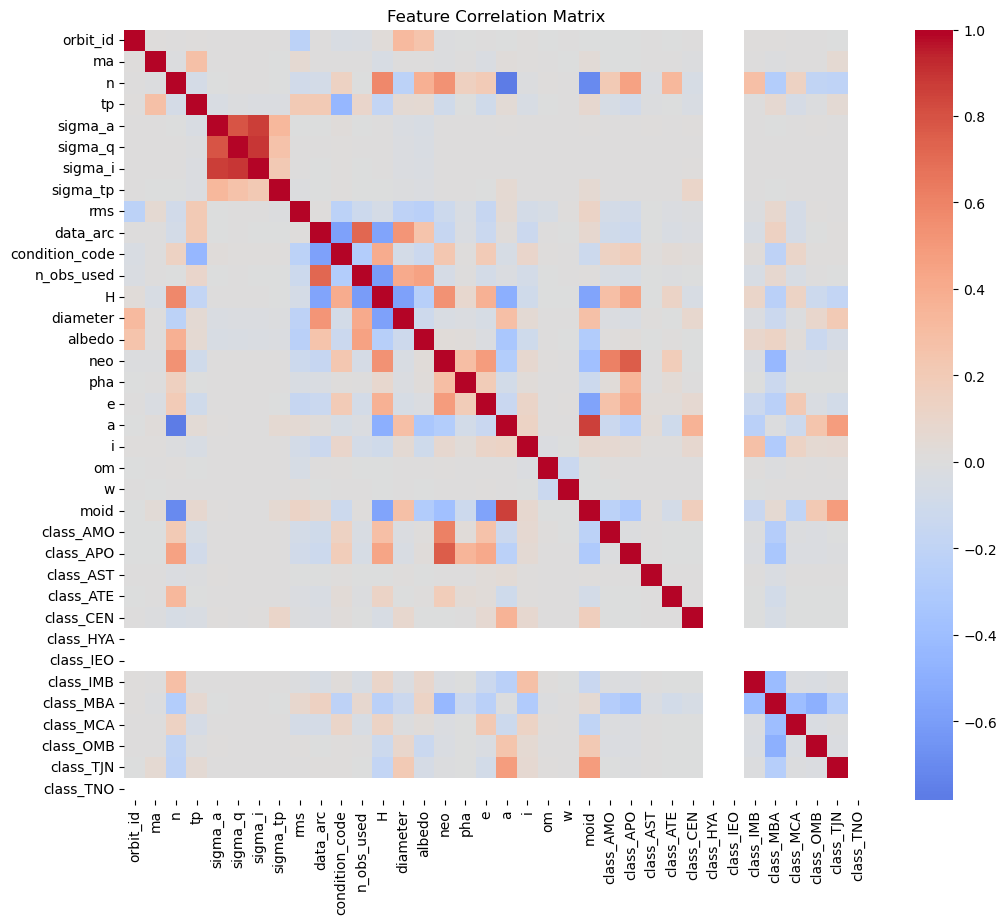

In [32]:
# 4.4 Visualize Final Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

#### 🧾 5. Drop Features with No Correlation to Target

In [33]:
# Drop features with no correlation
asteroid = asteroid.drop(columns = ['class_HYA','class_IEO','class_TNO'])

#### 💾 6. Save Cleaned Dataset

In [34]:
# Save the cleaned dataset as a csv file before further regression
asteroid.to_csv("data/asteroid_cleaned.csv",index=True)

### ☄️ NEO Dataset Cleaning & Preprocessing

#### 🔍 1. Initial Inspection

In [35]:
# Print original shape of the dataset (rows, columns)
print(df_neo.shape)

# View all column names
df_neo.columns

(90836, 10)


Index(['id', 'name', 'est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object',
       'absolute_magnitude', 'hazardous'],
      dtype='object')

In [36]:
# Check for missing values in each column
df_neo.isna().sum()

id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

#### 🆔 2. Check Uniqueness of Identifiers

In [37]:
# Ensure unique combinations of 'id' and 'name'
print(df_neo[['id','name']].nunique())

id      27423
name    27423
dtype: int64


#### 🗃️ 3. Aggregating Duplicate NEO Entries

In [38]:
# Group by unique NEO identifier ('id' and 'name'), and aggregate values
# - Take first value for static fields (like diameter or orbiting body)
# - Use mean/min/max for dynamic values (like velocity and miss distance)

df_neo_unique = df_neo.groupby(['id','name']).agg({
    'est_diameter_min': 'first',
    'est_diameter_max': 'first',
    'absolute_magnitude': 'first',
    'orbiting_body': 'first',
    'sentry_object': 'first',
    'hazardous': 'first',
    'relative_velocity': ['mean', 'min', 'max'],
    'miss_distance': ['mean', 'min', 'max']
}).reset_index()

#### 🔃 4. Flatten Multi-Level Column Names

In [39]:
# Flatten columns from multi-index format produced by aggregation
df_neo_unique.columns = [
    f"{col[0]}_{col[1]}" if col[1] not in ['first', ''] else col[0]
    for col in df_neo_unique.columns.values
]

# Check new shape after aggregation
print(df_neo_unique.shape)

(27423, 14)


#### 🧹 5. Drop Irrelevant or Redundant Columns

In [40]:
# Dropping irrelevant columns
df_neo_unique = df_neo_unique.drop(columns=['id','orbiting_body','sentry_object'])
print(df_neo_unique.shape)

(27423, 11)


#### 🔁 6. Convert and Reindex

In [41]:
# Converting "hazardous" feature to integers (0 and 1)
df_neo_unique['hazardous'] = df_neo_unique['hazardous'].astype(int)

# Set 'name' as index for easier referencing
df_neo_unique.set_index('name', inplace=True)

#### ➕ 7. Feature Engineering

In [42]:
# Create a new column for mean estimated diameter
df_neo_unique['est_diameter_mean'] = (
    df_neo_unique['est_diameter_min'] + df_neo_unique['est_diameter_max']
) / 2
# Create a new column for average relative velocity
df_neo_unique['relative_velocity_mean'] = (
    df_neo_unique['relative_velocity_min'] + df_neo_unique['relative_velocity_max']
) / 2

# Check shape after feature creation
print(df_neo_unique.shape)

(27423, 11)


#### 🧽 8. Drop Redundant Features After Merging

In [43]:
# Dropping features not needed
df_neo_unique = df_neo_unique.drop(columns=['est_diameter_min','est_diameter_max','relative_velocity_min','relative_velocity_max','miss_distance_min','miss_distance_max'])
print(df_neo_unique.shape)

(27423, 5)


#### 👀 9. Preview Final Dataset

In [44]:
df_neo_unique.head()

,absolute_magnitude,hazardous,relative_velocity_mean,miss_distance_mean,est_diameter_mean
name,,,,,
433 Eros (A898 PA),10.31,0,18822.978025,3.754117e+07,37.285727
719 Albert (A911 TB),15.57,0,27551.597194,4.258288e+07,3.307826
1036 Ganymed (A924 UB),9.23,0,51496.923293,5.372124e+07,61.311595
1566 Icarus (1949 MA),16.35,1,106877.628177,4.609560e+07,2.309631
1580 Betulia (1950 KA),14.69,0,107171.338891,4.413007e+07,4.960696


#### 💾 10. Save Cleaned Dataset for Modeling

In [45]:
# Save dataset as a csv file for last modelling
df_neo_unique.to_csv("data/neo_cleaned.csv",index=True)